In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples, get_wasserstein_dist, get_delta_R_neighbors_numba_exact, get_delta_R_neighbors_kdtree
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d


plt.style.use("../science.mplstyle")

In [2]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
NUM_BDTS = 10

collections = [
    "InnerTrackerBarrelCollection",
    "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]


ZUKO_ID = "NCSF"
NAME = "M_4096_rphi"
NUM_COND_INPUTS = 0
SEED = 8

EVALUATE_SAMPLES = False

FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = [1]



In [14]:
# load in samples

all_data_dir, all_samples_dir = {}, {}
bins_dict, bins_dict_preproc = {}, {}
aucs = {}

for col_name in collections:
    small_id = ''.join([c for c in col_name if c.isupper()])
    data, _, feature_labels = load_in_data([col_name], FEATURES, working_dir, 0.5)
    all_data_dir[col_name] = data
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
    with open(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/results.txt") as ifile:
        aucs[col_name]=  ifile.readlines()[-1]
   

# if FEATURES == "rphi":
#     r = np.sqrt(flow_samples[:, 1]**2 + flow_samples[:, 2]**2)
#     theta = np.arctan2(flow_samples[:, 2], flow_samples[:, 1])
#     flow_samples[:,1] = r
#     flow_samples[:,2] = theta

    bins_dict[col_name] = {}
    bins_dict_preproc[col_name] = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}
    
    for i in range(data.shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), NUM_BINS) 
        else:
            bins_dict[col_name][i] = np.linspace(np.min(data[:,i] - 3), np.max(data[:,i] + 3), NUM_BINS) 

In [15]:
print(aucs)

{'InnerTrackerBarrelCollection': 'auc 0.6885031255037279 pm 0.0005325740701719373. best epoch [999, 999, 999, 999, 999] of 1000.\n', 'InnerTrackerEndcapCollection': 'auc 0.9824140347303952 pm 1.6469628144615147e-05. best epoch [999, 999, 999, 999, 999] of 1000.\n', 'OuterTrackerBarrelCollection': 'auc 0.6678291384792465 pm 0.00025226187424907194. best epoch [999, 999, 999, 999, 999] of 1000.\n', 'OuterTrackerEndcapCollection': 'auc 0.9897065293701536 pm 9.176323407433712e-06. best epoch [997, 999, 998, 999, 998] of 1000.\n', 'VertexBarrelCollection': 'auc 0.668378110274704 pm 0.00216250523086507. best epoch [999, 813, 995, 999, 999] of 1000.\n', 'VertexEndcapCollection': 'auc 0.96486115793615 pm 4.6115703614642395e-05. best epoch [999, 999, 999, 999, 999] of 1000.\n'}


InnerTrackerBarrelCollection


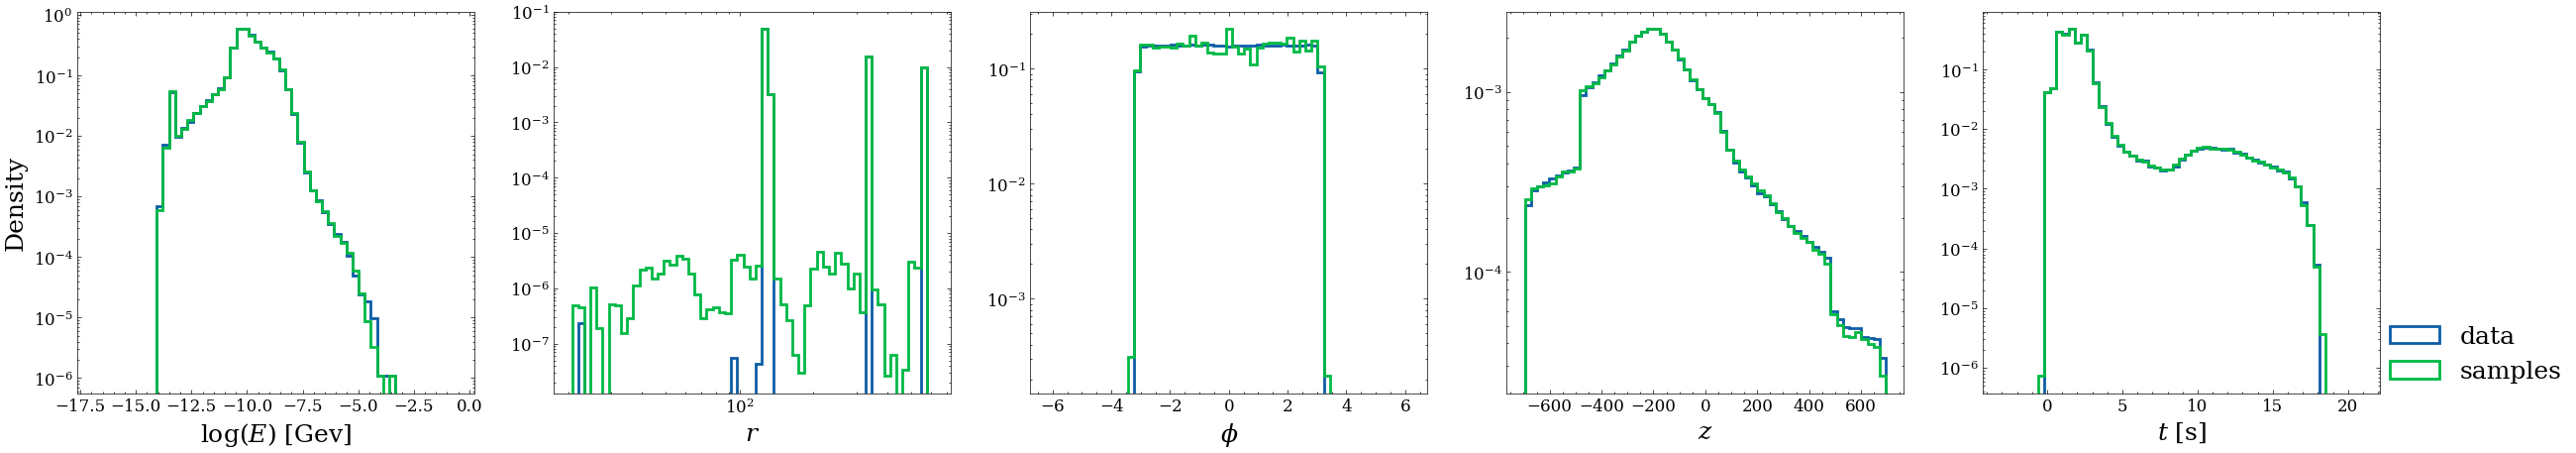

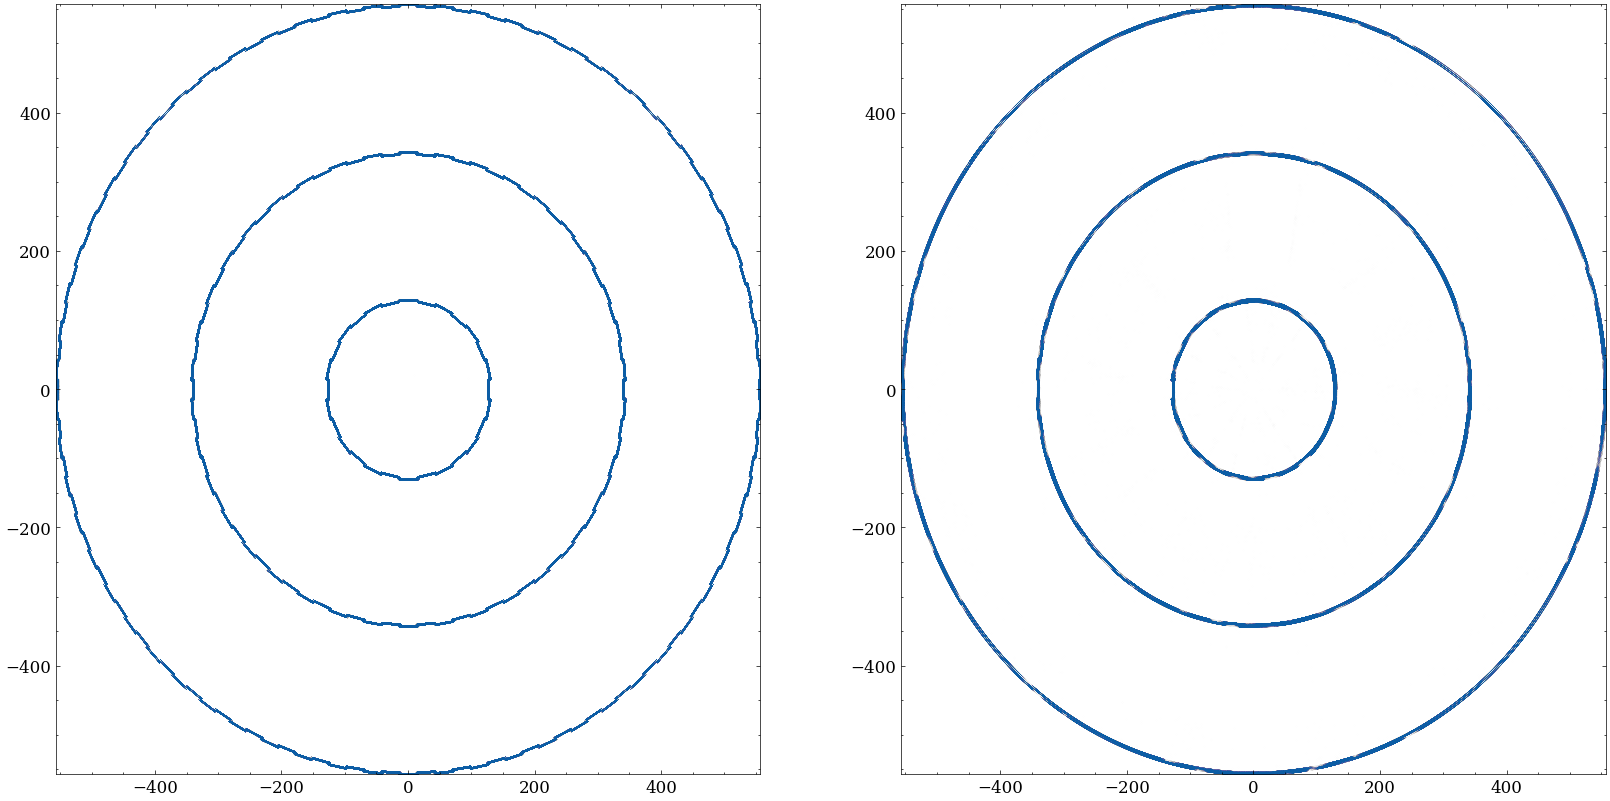

InnerTrackerEndcapCollection


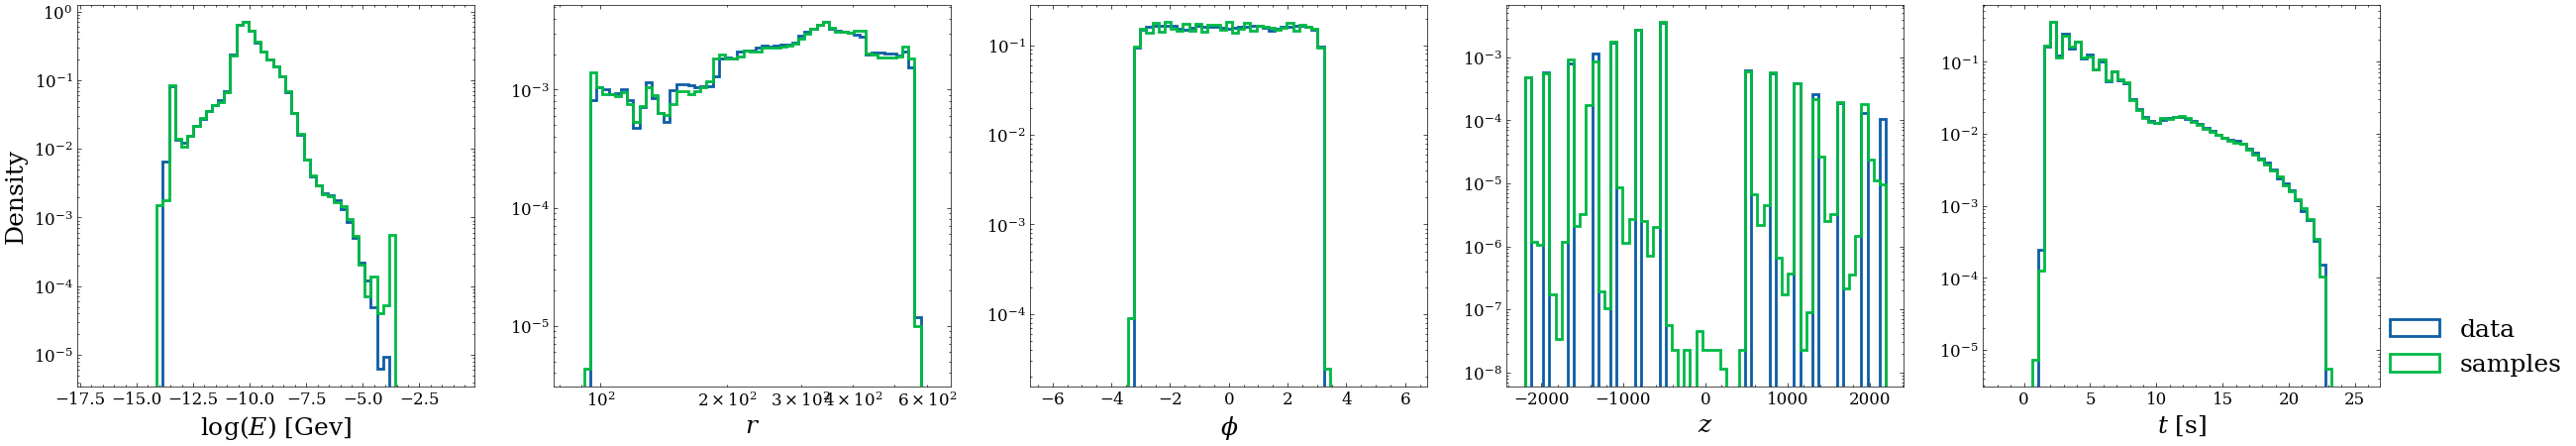

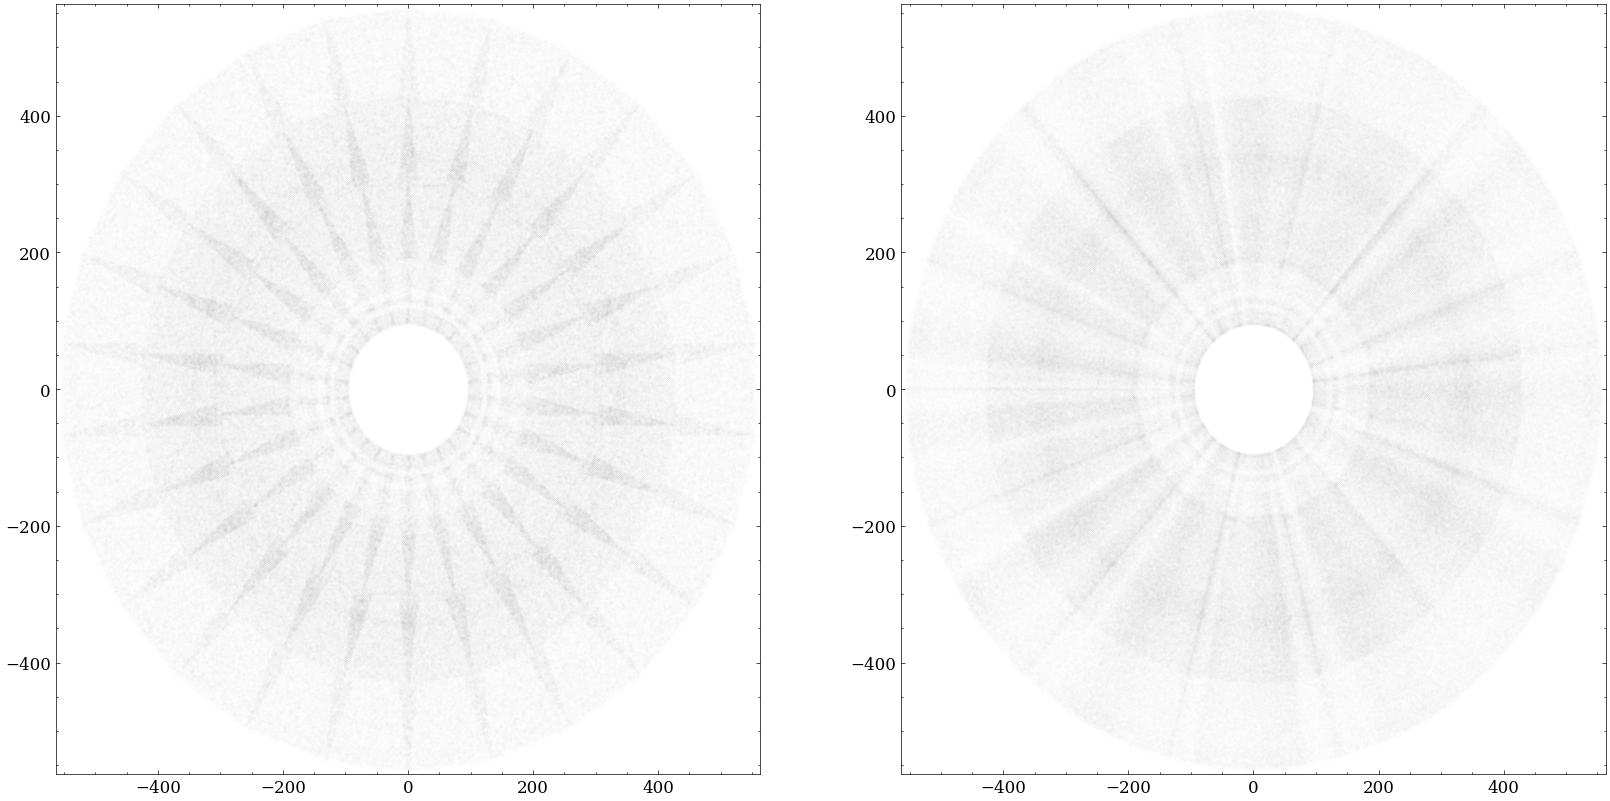

OuterTrackerBarrelCollection


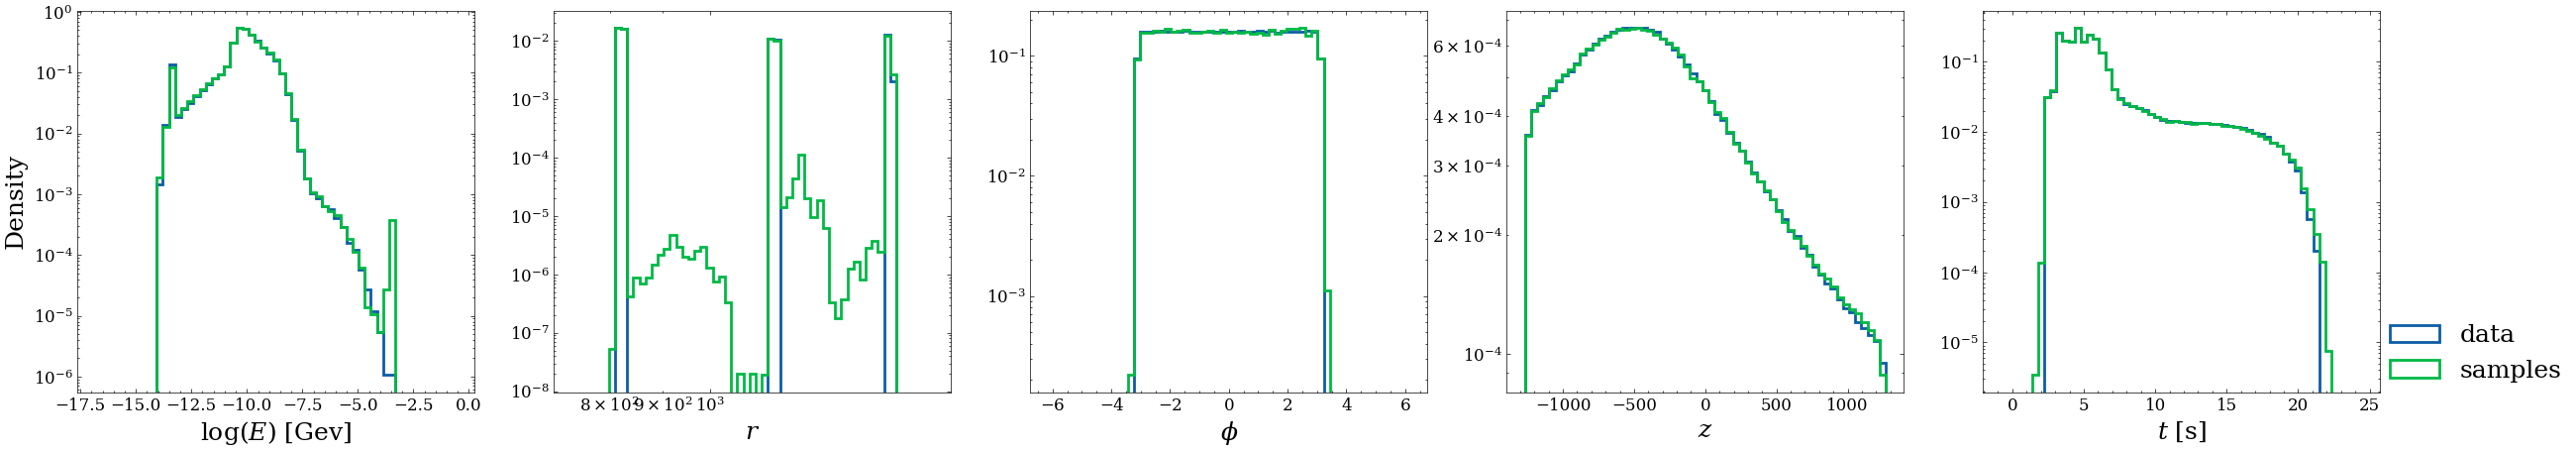

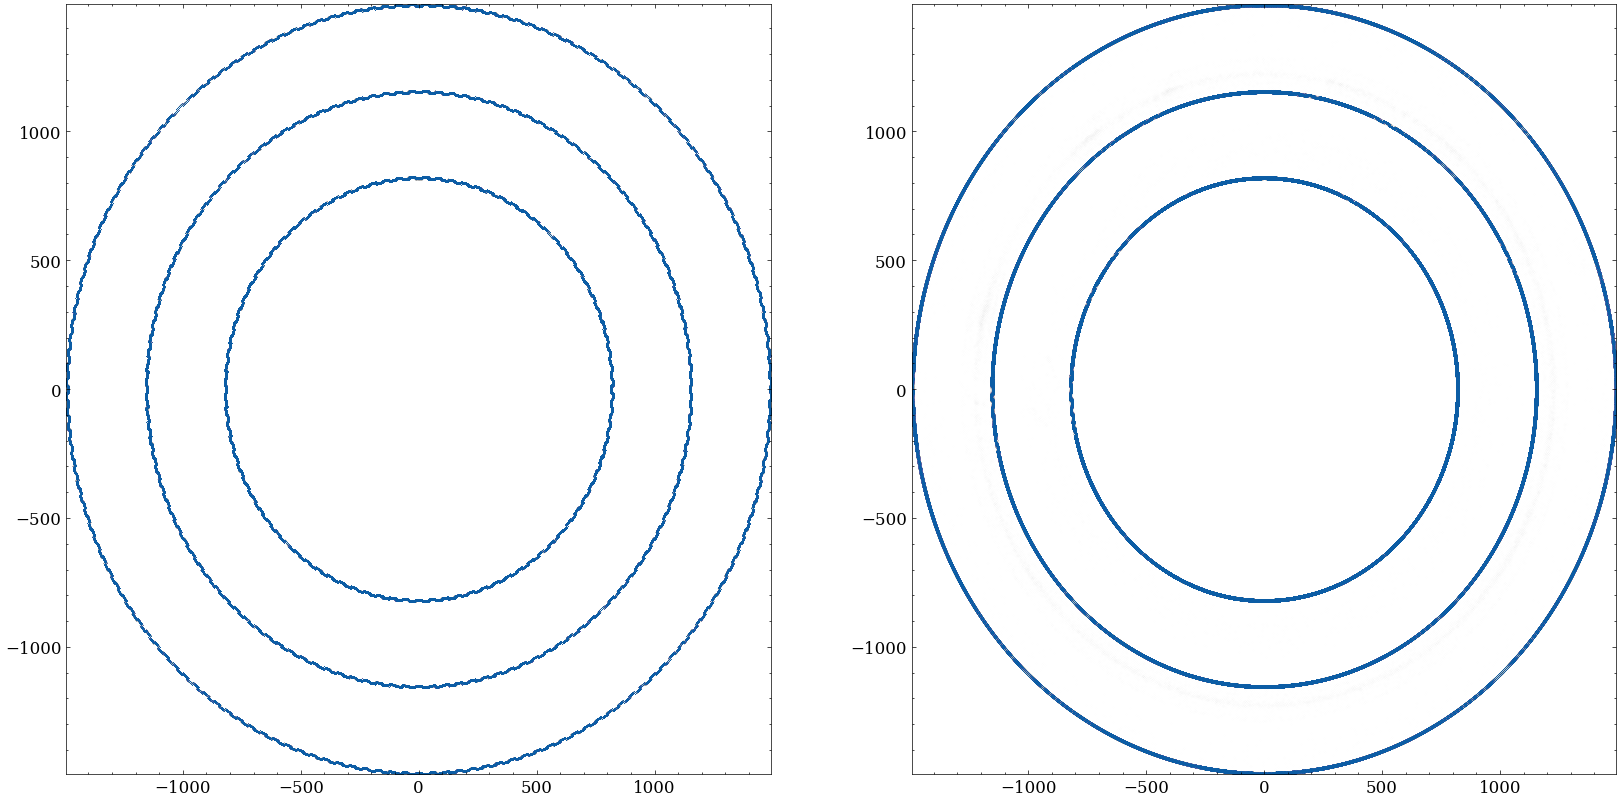

OuterTrackerEndcapCollection


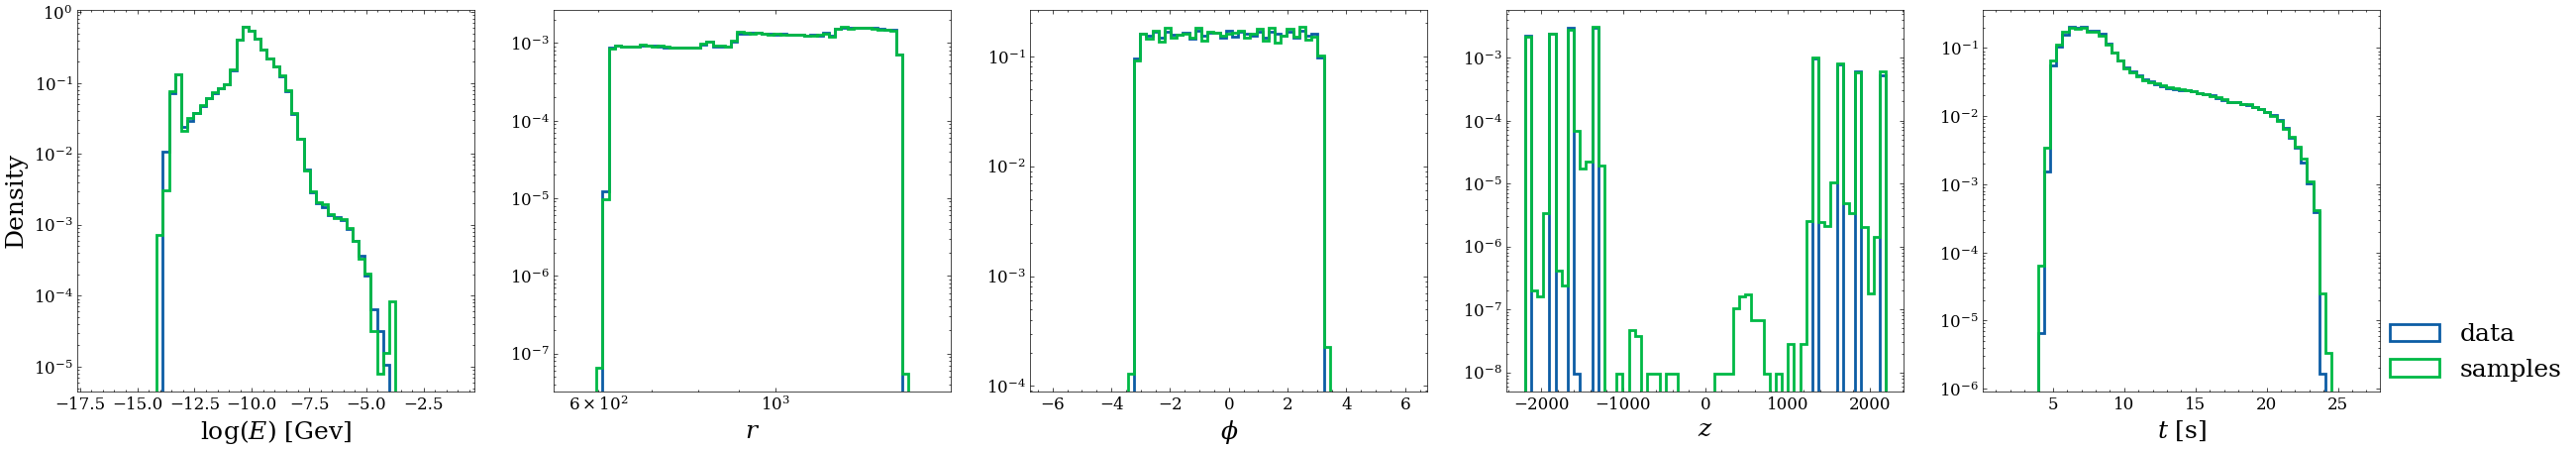

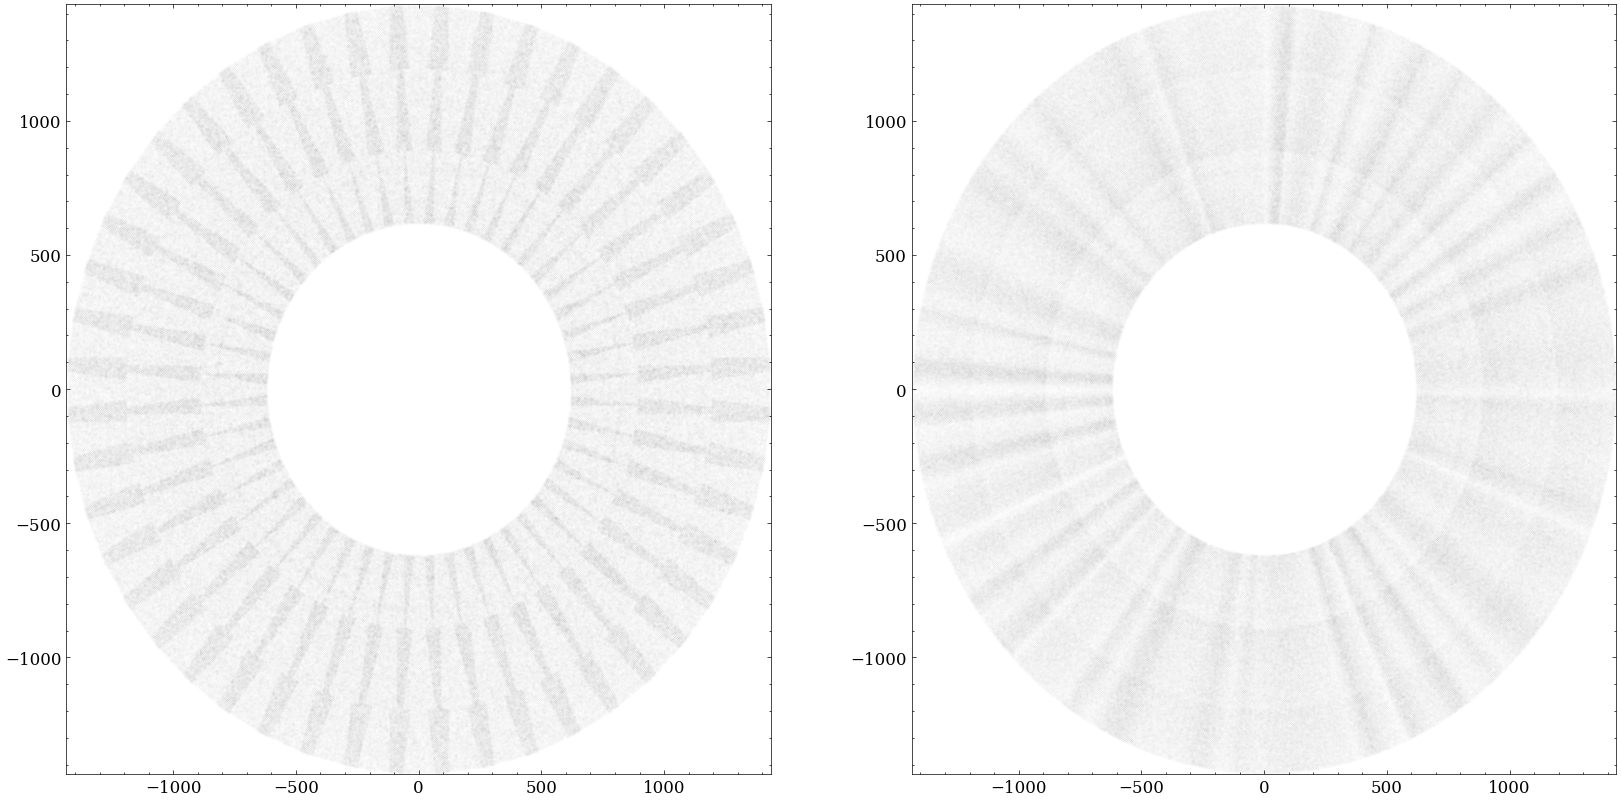

VertexBarrelCollection


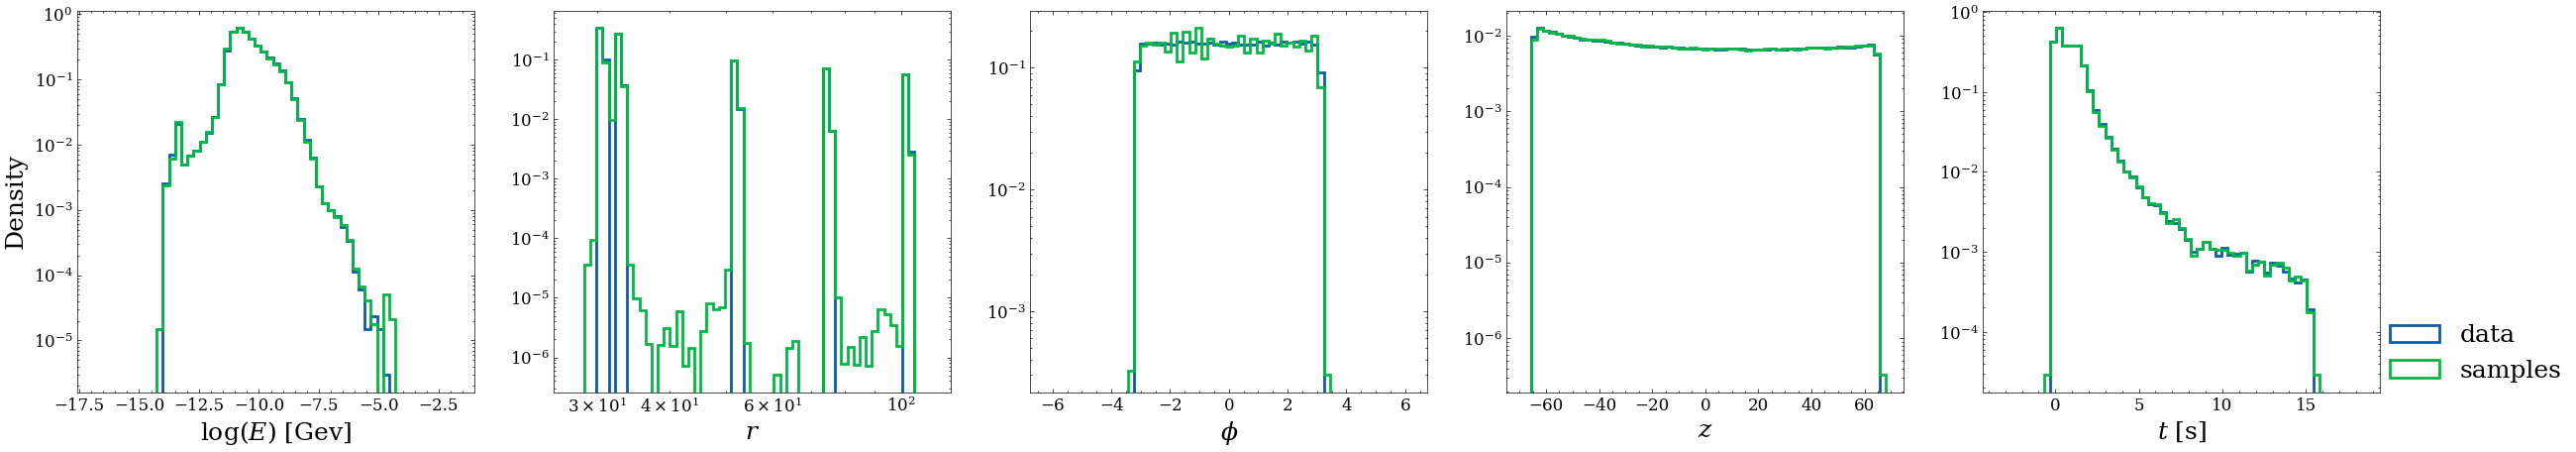

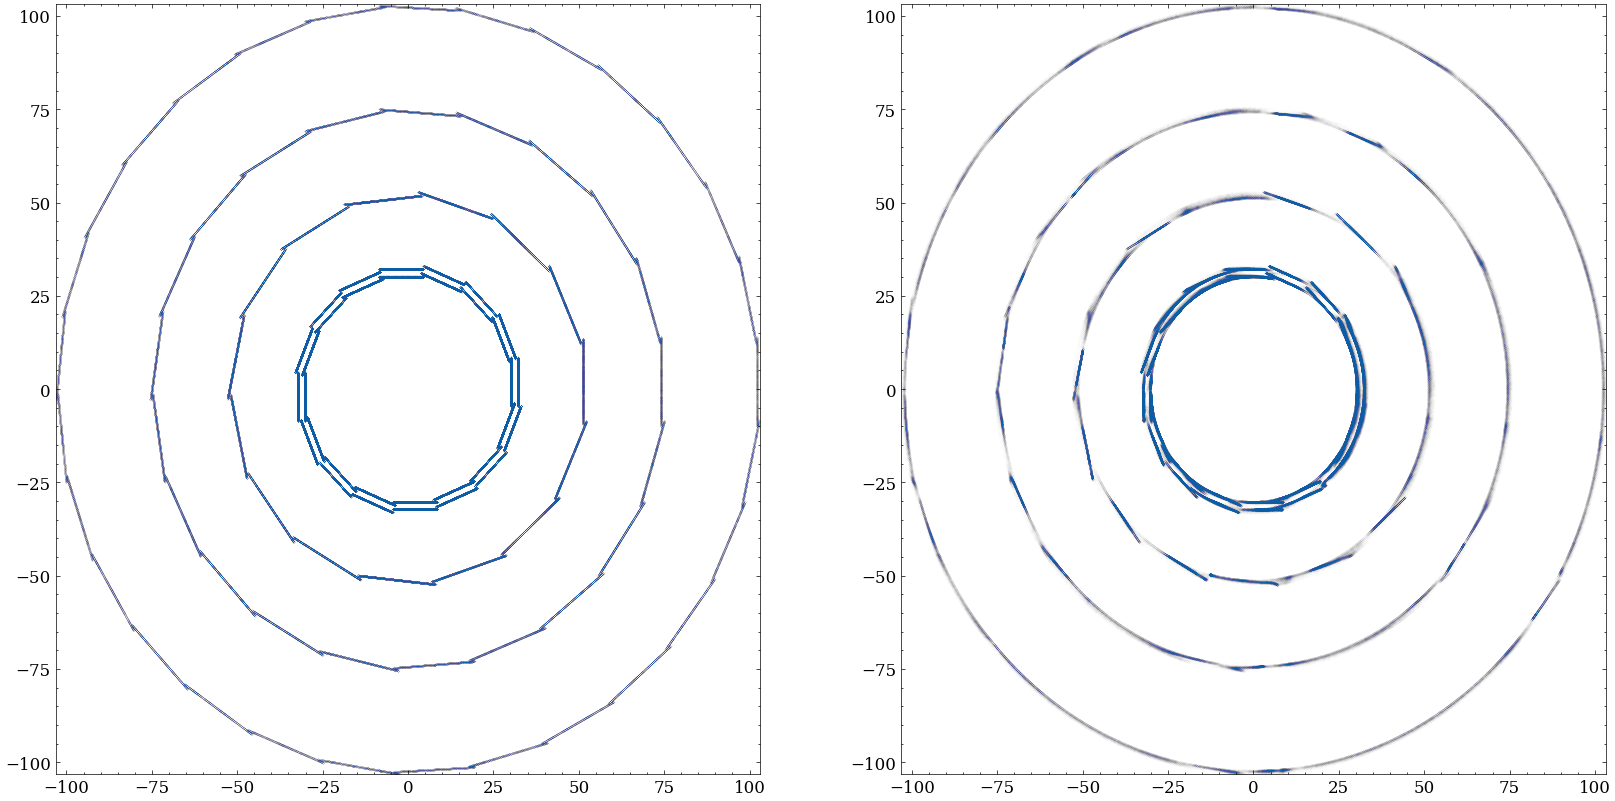

VertexEndcapCollection


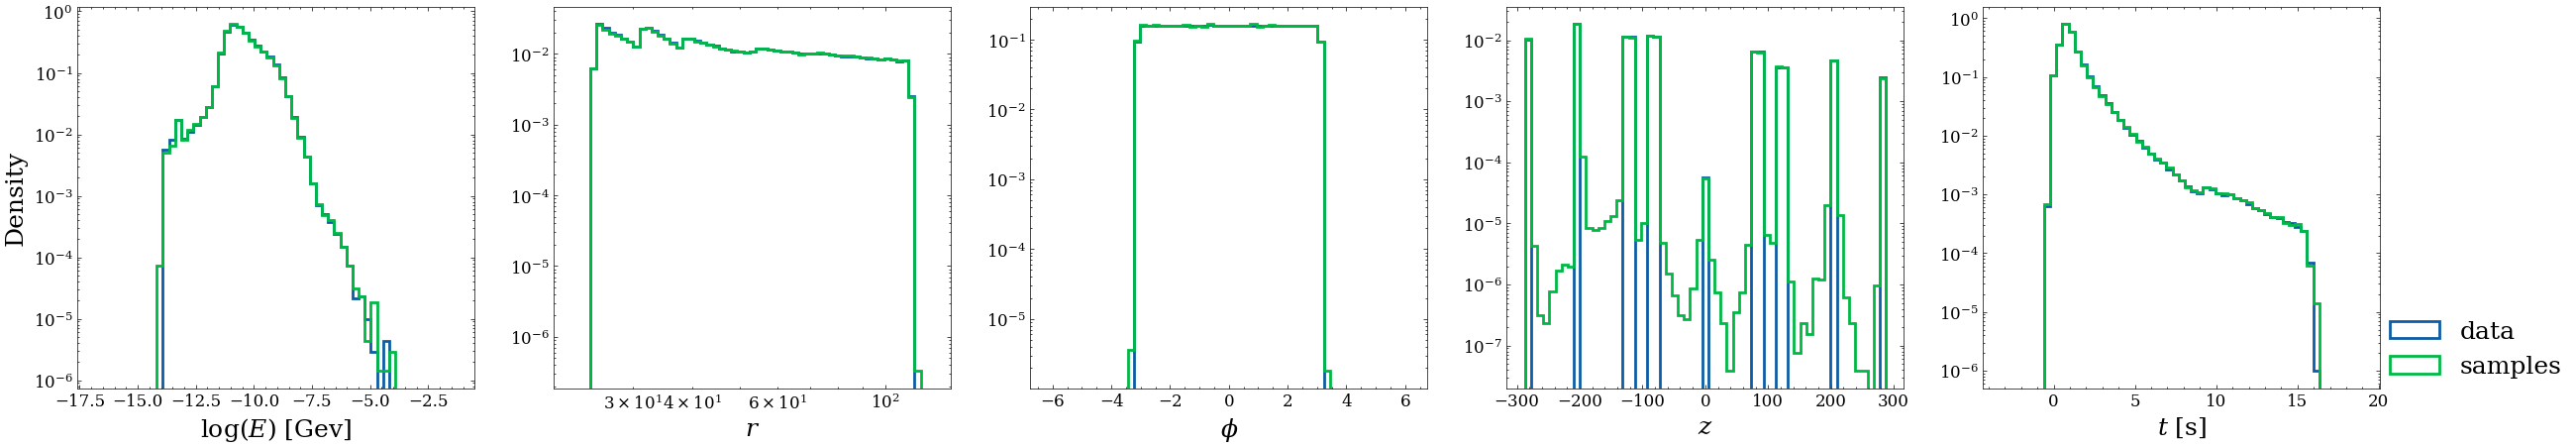

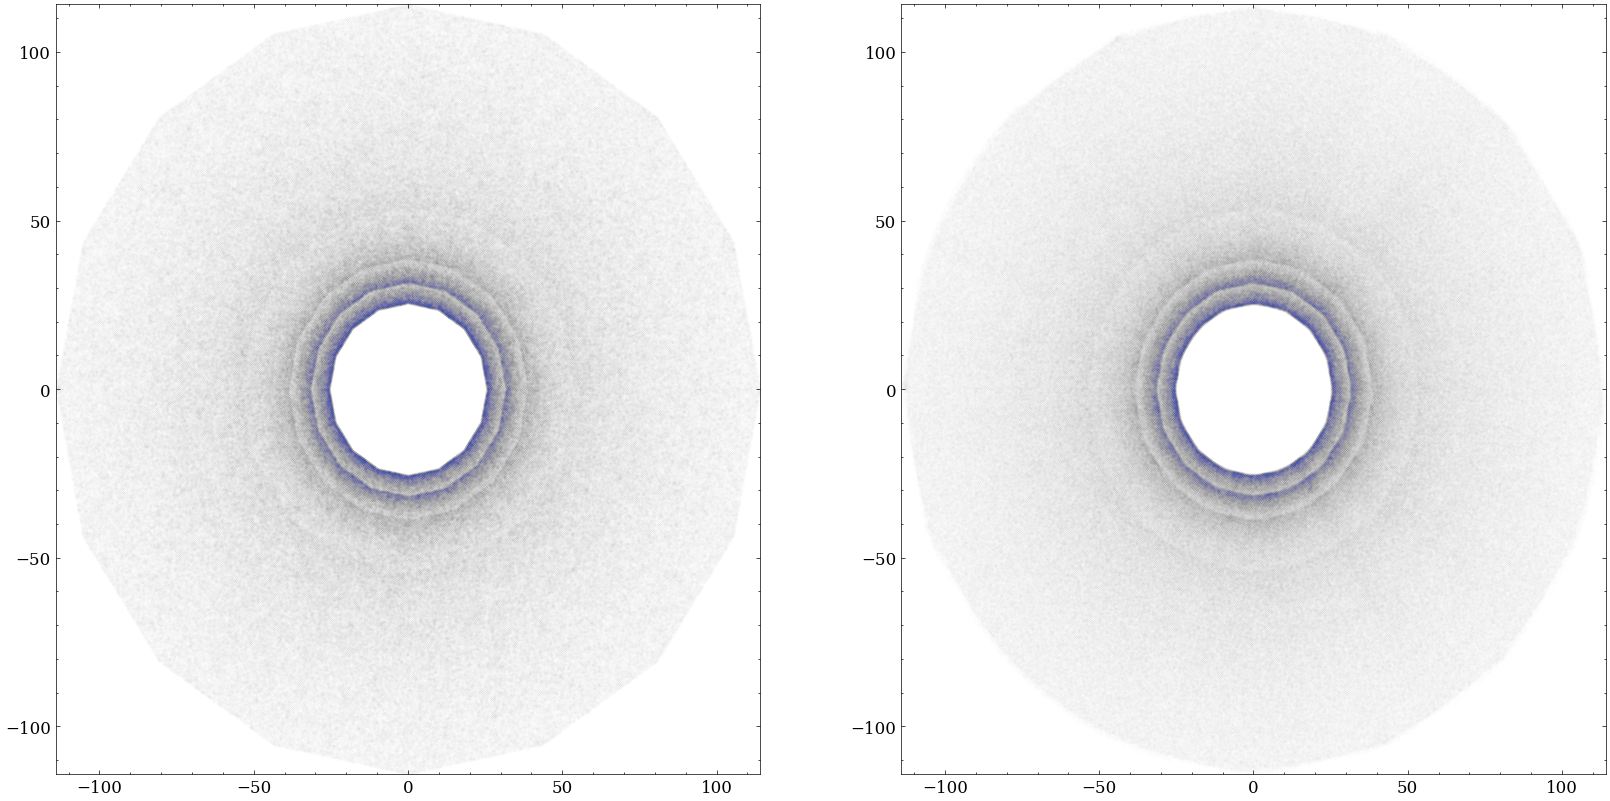

In [12]:
for col_name in collections:

    print(col_name)
    plot_hists_1d({"data":all_data_dir[col_name], "samples": all_samples_dir[col_name]}, bins_dict[col_name], log_dims=log_vars, labels=feature_labels)
    plt.savefig(f"figures/{col_name}_1d.png")

    # plot x-y
    x_lim = np.max(all_data_dir[col_name][:,1])
    fig, ax = plt.subplots(1, 2, figsize = (20, 10))
    ax[0].scatter(all_data_dir[col_name][:,1]*np.cos(all_data_dir[col_name][:,2]), all_data_dir[col_name][:,1]*np.sin(all_data_dir[col_name][:,2]), s = 0.00001)
    ax[0].set_xlim(-x_lim, x_lim)
    ax[0].set_ylim(-x_lim, x_lim)
    
    ax[1].scatter(all_samples_dir[col_name][:,1]*np.cos(all_samples_dir[col_name][:,2]), all_samples_dir[col_name][:,1]*np.sin(all_samples_dir[col_name][:,2]), s = 0.00001)
    ax[1].set_xlim(-x_lim, x_lim)
    ax[1].set_ylim(-x_lim, x_lim)
    plt.show()
    
   

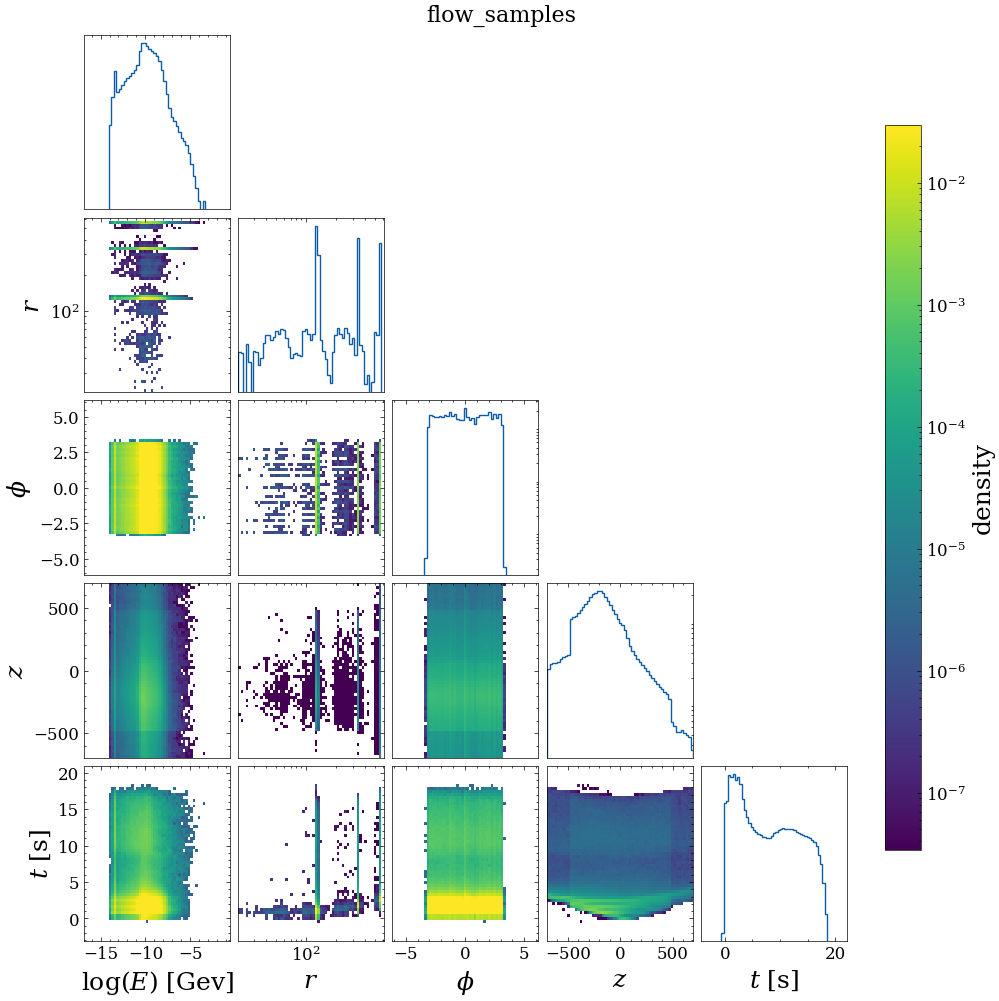

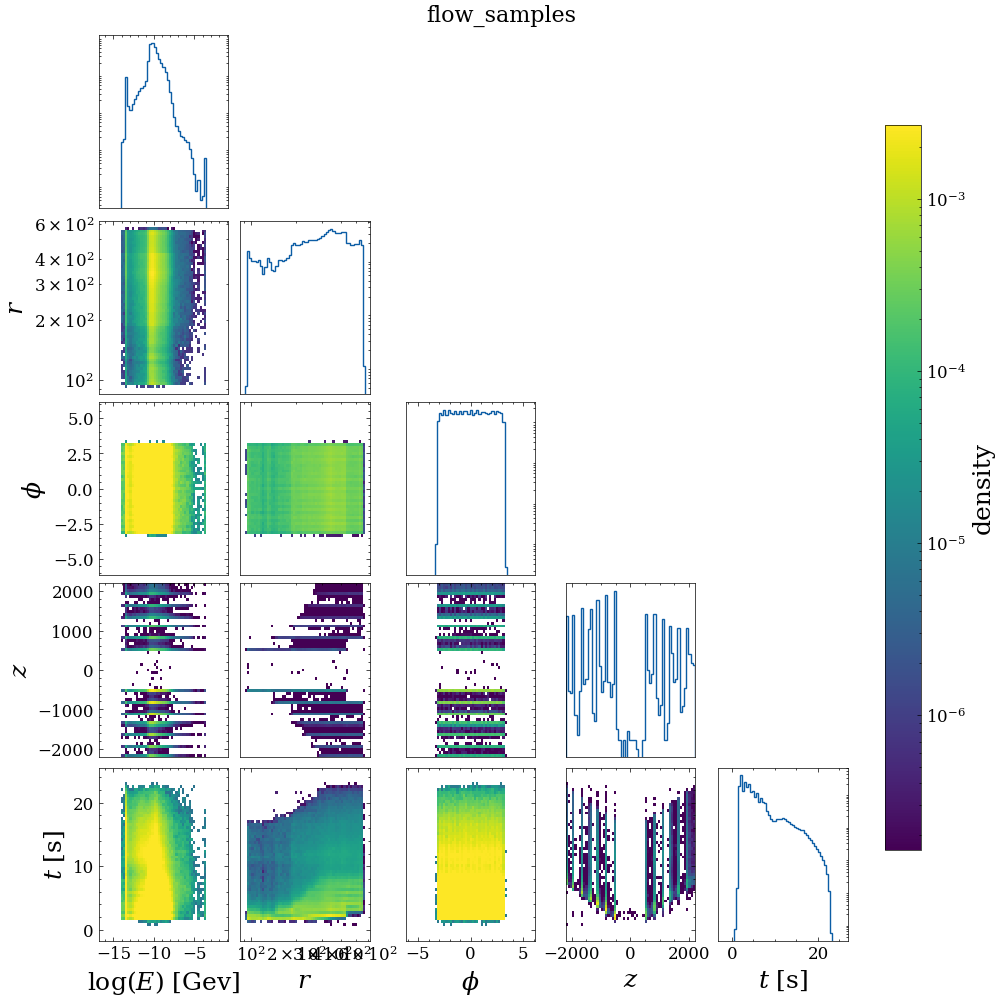

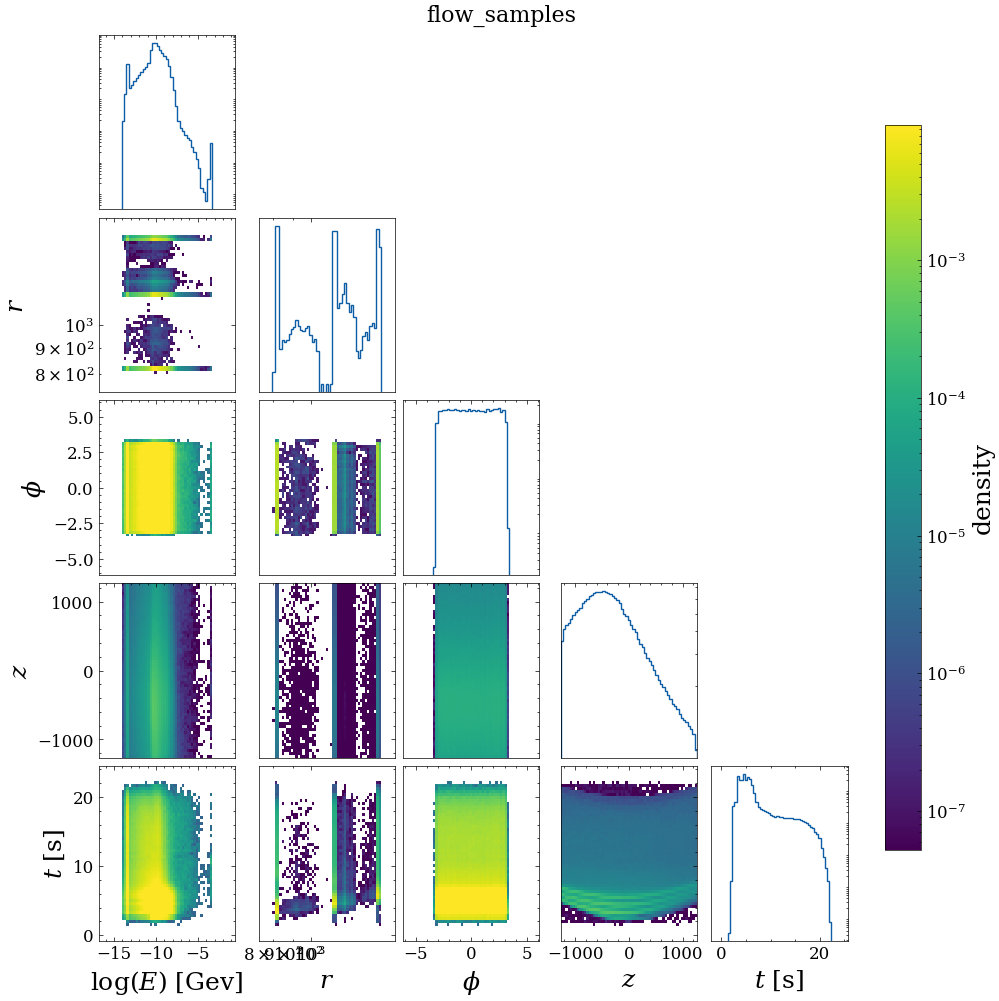

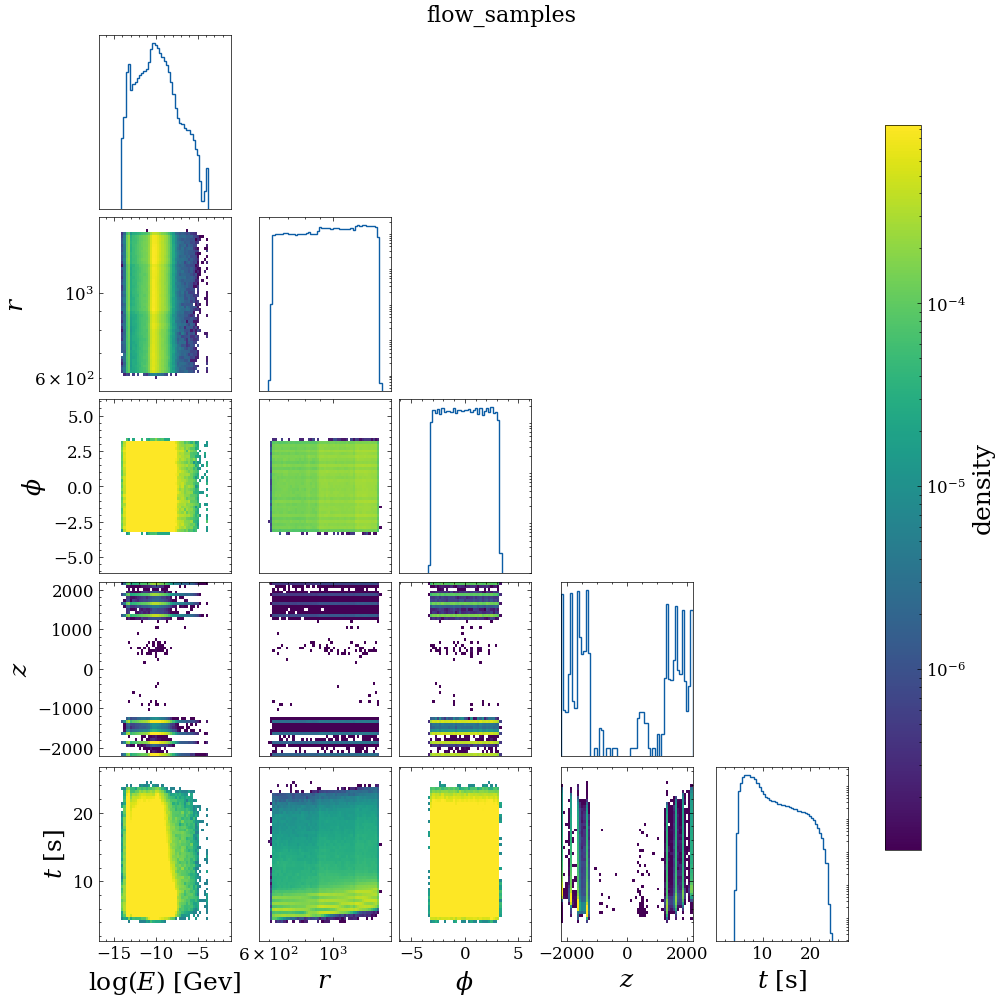

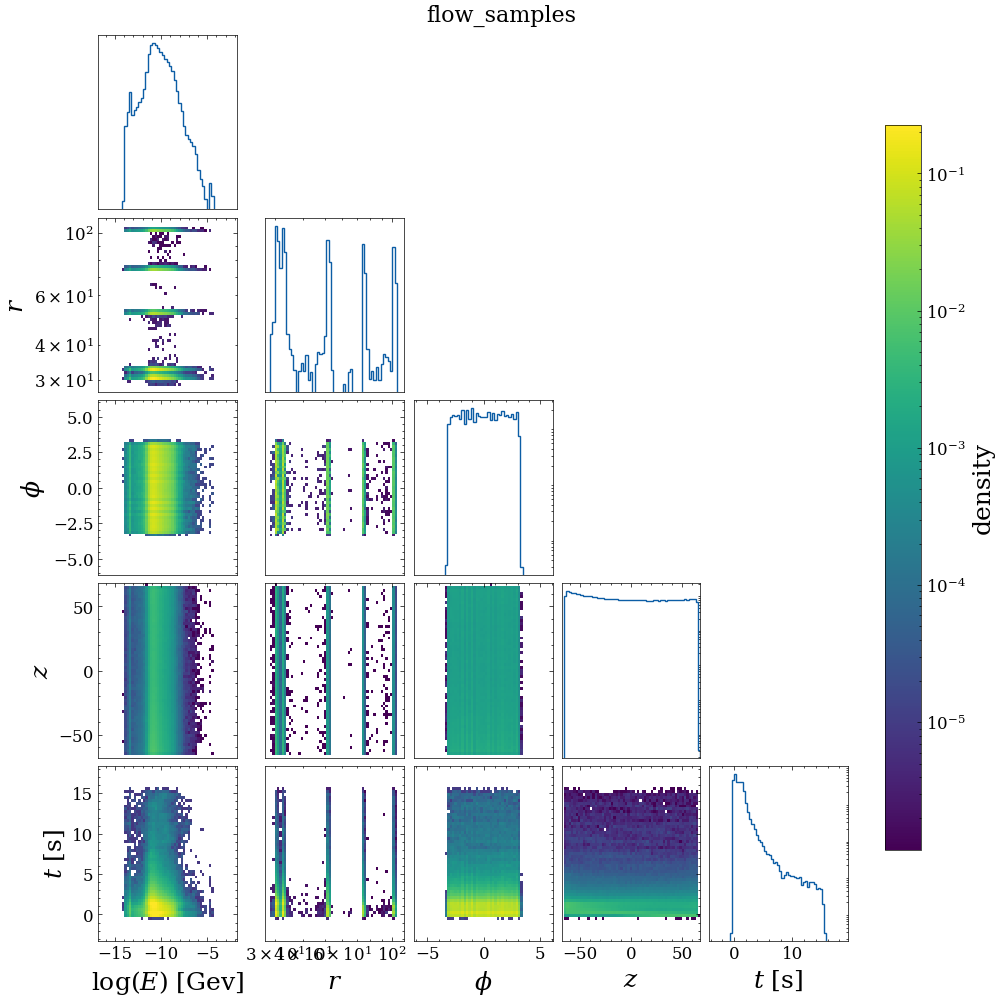

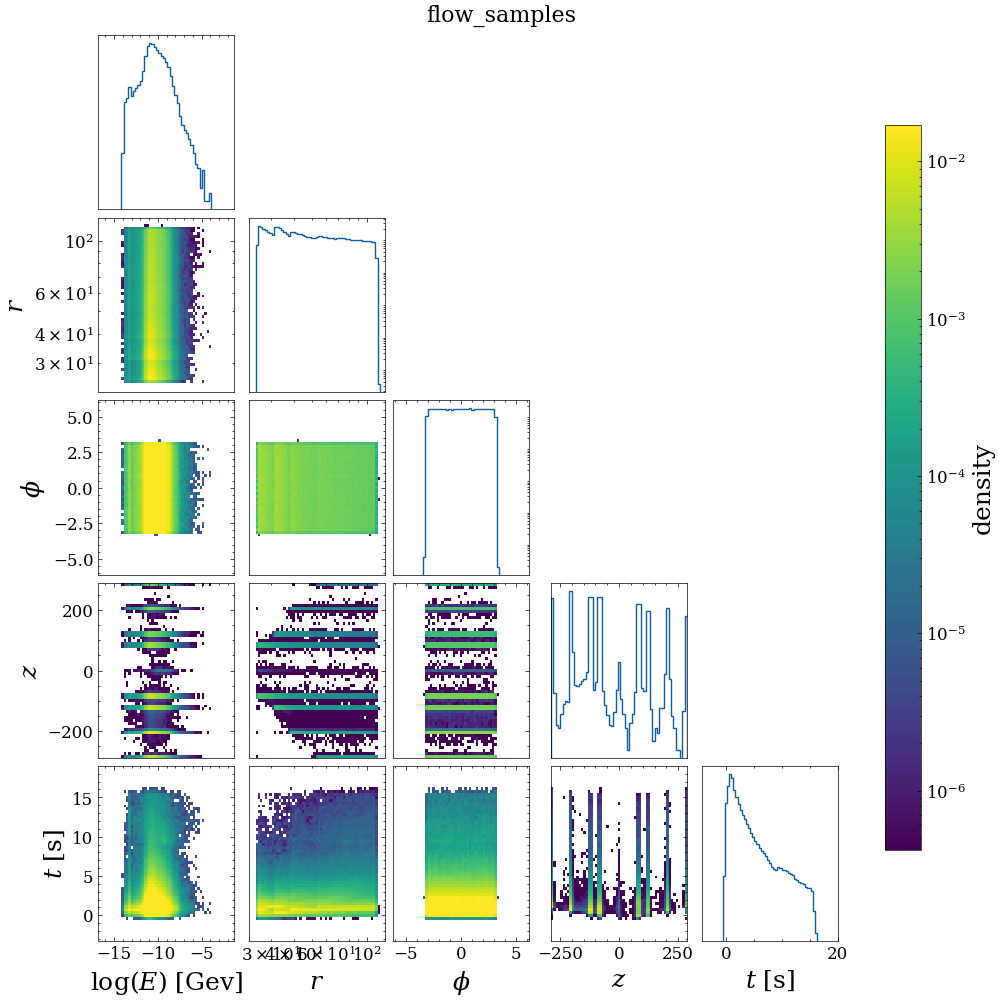

In [17]:
for col_name in collections:
    fig_samp, axes_samp = plot_corner_hist_2d(
       all_samples_dir[col_name],
        feature_labels=feature_labels,
        bins_dict=bins_dict[col_name],
        log_dims=log_vars,
        title= "flow_samples",
    )
    plt.savefig(f"figures/{col_name}_2d.png")


# Restrict layers


In [ ]:
import pickle
# https://github.com/key4hep/k4geo/blob/main/MuColl/MAIA/compact/MAIA_v0/OuterTracker_o2_v06_01.xml
with open("mask_definitions.pkl", "rb") as ifile:
    mask_definitions = pickle.load(ifile)



def make_mask(r):

    with open("mask_definitions.pkl", "rb") as ifile:
        mask_definitions = pickle.load(ifile)

    mask = []
    for radius in mask_definitions[COLLECTION_NAME].keys():
        for i in range(len(mask_definitions[COLLECTION_NAME][radius]["lower_bounds"])):
           
    
            tmp = (
                (r >= mask_definitions[COLLECTION_NAME][radius]["lower_bounds"][i]) &
                (r <= mask_definitions[COLLECTION_NAME][radius]["upper_bounds"][i])
            )
    
            mask.append(tmp.reshape(-1,1))

    mask = np.any(np.hstack(mask), axis=1)

    return mask


for col_name in mask_definitions.keys():
    print(col_name)
    for r in mask_definitions[col_name].keys():
        print("r:", r)
        print("   lower bounds:", mask_definitions[col_name][r]["lower_bounds"])
        print("   upper bounds:", mask_definitions[col_name][r]["upper_bounds"])
    print()

In [ ]:
if FEATURES == "rphi":
    r_data = data[:,1]
    r_flow = flow_samples[:,1]
else: 
    r_data = np.sqrt(data[:,1]**2+data[:,2]**2)
    r_flow = np.sqrt(flow_samples[:,1]**2+flow_samples[:,2]**2)

mask_flow = make_mask(r_flow)

print("Num. data samples:", len(r_data))
print("Num. flow samples:",len(mask_flow), "\nNum. flow samples pass mask:", sum(mask_flow), "\n% flow samples pass mask:", sum(mask_flow)/len(mask_flow))


plt.figure()
plt.hist(r_data, bins = np.linspace(0, 1500, 1000), histtype = "step", label = "data")
plt.hist(r_flow, bins = np.linspace(0, 1500, 1000), histtype = "step", label = "flow")
plt.legend()
plt.yscale("log")
plt.xlabel("$r$ [mm]")
plt.ylabel("Counts")
plt.show()

In [ ]:

for radius in mask_definitions[COLLECTION_NAME].keys():

    bins = np.linspace(radius - 10, radius + 10, 1000)
   

    plt.figure(figsize = (10, 5))
    for j in range(len(mask_definitions[COLLECTION_NAME][radius]["lower_bounds"])):
        plt.axvspan(mask_definitions[COLLECTION_NAME][radius]["lower_bounds"][j], mask_definitions[COLLECTION_NAME][radius]["upper_bounds"][j], alpha = 0.5, color = "pink")
        
    plt.hist(r_flow, bins = bins, histtype = "step", label = "flow", density = True)
    plt.hist(r_flow[mask_flow], bins = bins, histtype = "step", label = "masked flow", density = True)
    plt.hist(r_data, bins = bins, histtype = "step", label = "data", density = True)
    plt.xlim([radius - 10, radius + 10])
    plt.axvline(radius, color = "r")
    plt.legend()

    plt.title(f"{COLLECTION_NAME}\nr={radius}mm")
    plt.yscale("log")
    plt.xlabel("$r$ [mm]")
    plt.ylabel("Density")
    plt.show()

In [ ]:
plot_hists_1d({"samples":flow_samples, "masked flow samples":flow_samples[mask_flow]}, bins_dict, log_dims=log_vars, labels=feature_labels)


fig_samp, axes_samp = plot_corner_hist_2d(
        flow_samples,
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= "flow samples",
    )



fig_samp, axes_samp = plot_corner_hist_2d(
        flow_samples[mask_flow],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= "masked flow samples",
    )

In [23]:
import torch

device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)

def run_eval_suite(data, samples, R_values, plot_suffix=""):

    print(f"Len data: {len(data)}, len samples: {len(samples)}")


    # Wasserstein dist
    # wass_dists_samples = get_wasserstein_dist(data, samples)
    # wass_dists_gaussians = get_wasserstein_dist(np.random.normal(size = data.shape), np.random.normal(size = samples.shape))                                            
    # for i, wass_dist in enumerate(wass_dists_samples):
    #     print("Feature {i} Wasserstein distance: {wass_dist} (for gaussian: {wass_dist_gauss})".format(i=i, wass_dist=wass_dist, wass_dist_gauss=wass_dists_gaussians[i]))

    # BDT
    auc_mean, auc_std, best_epoch_list, max_epochs, bdt_list, samples_test, loc_scores = discriminate_data_from_samples(
                                            data,
                                            samples,
                                            3,
                                            "configs/bdt.yml",
                                            model_type="bdt",
                                            plot_losses=True,
                                            device="cuda",
                                            val_size = 0.25, 
                                            plot_dir="."
                                        )

    print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")

    
    plt.figure()
    plt.hist(loc_scores, bins = np.linspace(0, 1, 100), histtype = "step", density = True)
    plt.yscale("log")
    plt.xlabel("scores")
    plt.ylabel("Density")
    plt.show()
    
    
    X_plot = {"samples":  samples_test}
    percentiles = [90, 95, 99, 99.9]
    for p in percentiles:
        X_plot[f"samples, top {p}%"] =  samples_test[loc_scores >= np.percentile(loc_scores, p)]

    plot_hists_1d({"data":data, **X_plot}, bins_dict, log_dims=log_vars, labels=feature_labels)

    # Clustering
    for R in R_values:
        neighbor_counts_data = get_delta_R_neighbors_kdtree(data, R, FEATURES)
        neighbor_counts_flow = get_delta_R_neighbors_kdtree(samples, R, FEATURES)
    
        max_val0 = np.max(neighbor_counts_data)
        max_val1 = np.max(neighbor_counts_flow)
        max_val = np.max([max_val0, max_val1])
    
        bin_spacing = int(max_val/NUM_BINS)
        plt.figure()
        plt.hist(neighbor_counts_data, bins=np.arange(0, max_val, bin_spacing), histtype = "step", label = "data")
        plt.hist(neighbor_counts_flow, bins=np.arange(0, max_val, bin_spacing), histtype = "step", label = "flow")
        plt.legend()
        plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")
        plt.ylabel("Count")
        plt.savefig(f"figures/deltaR{R}{plot_suffix}.png")
        plt.show()



Using device: cuda


<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_366727/982967841.py:30: SyntaxWarning: invalid escape sequence '\p'
  print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
/tmp/ipykernel_366727/982967841.py:62: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")


Analyzing InnerTrackerBarrelCollection...
Len data: 100000, len samples: 100000
(100000, 5) (100000, 5)
On BDT run 1 of 3...


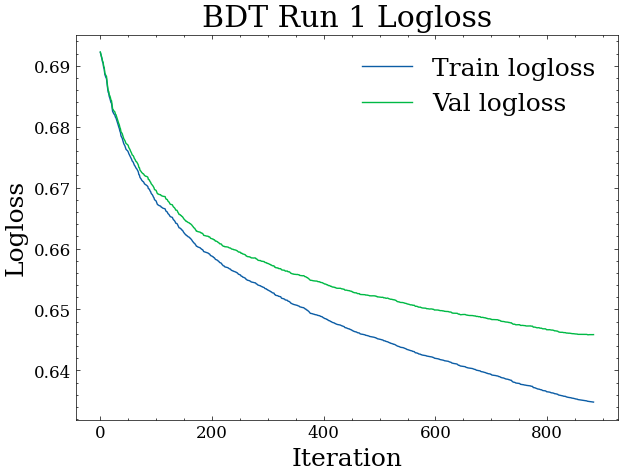

On BDT run 2 of 3...


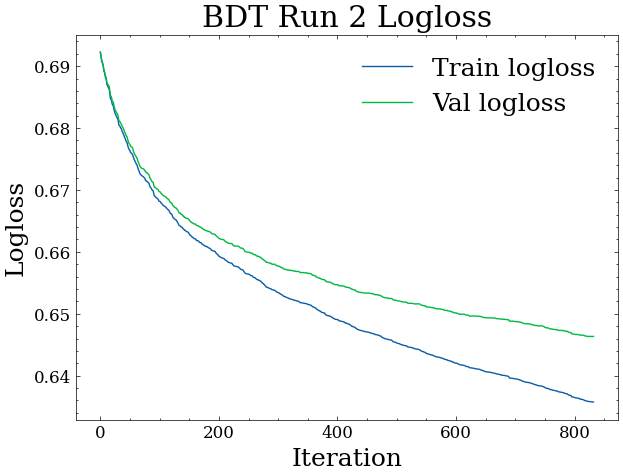

On BDT run 3 of 3...


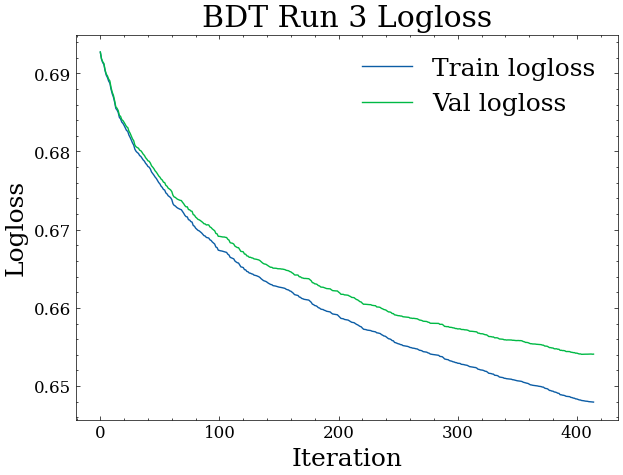

auc 0.6610356125333333 \pm 0.006690366011558867. best epoch [873, 822, 404] of 1000.



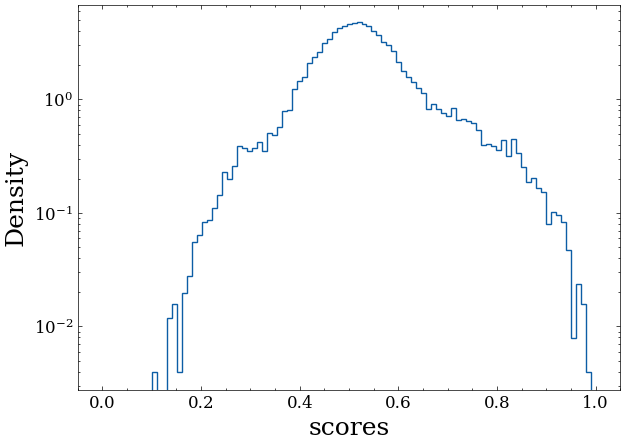

/tmp/ipykernel_366727/982967841.py:30: SyntaxWarning: invalid escape sequence '\p'
  print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")
/tmp/ipykernel_366727/982967841.py:62: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")


KeyError: 0

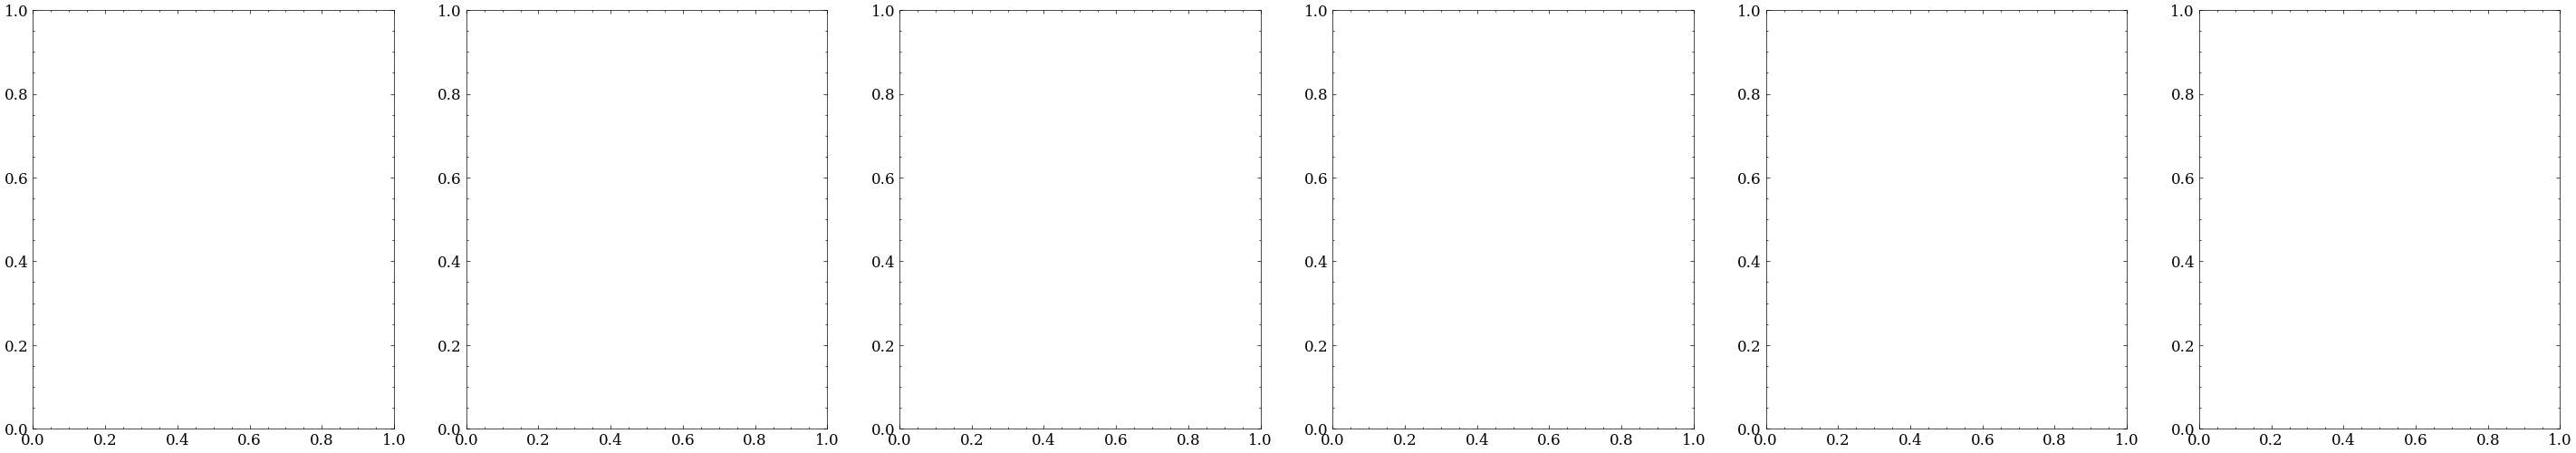

In [24]:
for col_name in collections:

    print(f"Analyzing {col_name}...")

    N = 100_000
    
    indices = np.random.choice(data.shape[0], size=N, replace=False)
    #indices_mask = np.random.choice(sum(mask_flow), size=N, replace=False)
    
    
    
    run_eval_suite(all_data_dir[col_name][indices], all_samples_dir[col_name][indices], [0.1, 0.2, 0.4],
                  plot_suffix=f"_{col_name}")

In [ ]:



run_eval_suite(data[indices], flow_samples[mask_flow][indices_mask], [0.1, 0.2, 0.4])